In [5]:
import pandas as pd

train_df = pd.read_csv('../data/train_data.csv')
sample = train_df.groupby('product', group_keys=False).apply(
    lambda x: x.sample(frac=0.006, random_state=42)
).reset_index(drop=True)
sample['risk_label'] = ''
sample[['narrative', 'product', 'risk_label']].to_csv(
    '../data/annotation_sample.csv', index=False
)

C:\Users\siewy\AppData\Local\Temp\ipykernel_16856\228598512.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = train_df.groupby('product', group_keys=False).apply(


In [ ]:
#annotaing using the annotation_guide 
import pandas as pd
import re

sample = pd.read_csv('../data/annotation_sample.csv')

HIGH_KEYWORDS = [
    r'\bsued\b', r'\blawsuit\b', r'\blegal action\b', r'\battorney\b', r'\bcourt\b',
    r'\bsummons\b', r'\bgarnish\b', r'\bwage garnishment\b', r'\bbank levy\b',
    r'\bbankruptcy\b', r'\bidentity theft\b', r'\bfraudulent account',
    r'\bopened.*account.*name\b', r'\bcannot (pay|afford)\b', r'\bcant (pay|afford)\b',
    r"\bcan't (pay|afford)\b", r'\bunable to (pay|afford)\b', r'\bno money for\b',
    r'\bcannot pay rent\b', r'\bcant pay rent\b', r'\beviction\b',
    r'\bfdcpa\b', r'\bscra\b', r'\bmilitary\b', r'\bdeployed\b',
    r'\bfixed income\b', r'\belderly\b', r'\bvulnerable\b',
    r'\bmedication\b.*\bcan.?t afford\b', r'\bfood\b.*\bcan.?t afford\b',
]

MEDIUM_KEYWORDS = [
    r'\bdenied (mortgage|loan|credit|housing|apartment|rental)\b',
    r'\bcredit (score|rating) (drop|fell|decreased|damaged)\b',
    r'\bscore dropped\b', r'\bdamaged.*credit\b',
    r'\bharassment\b', r'\bcalled.*times\b', r'\brepeat.*call\b',
    r'\brefused to investigate\b', r'\bno response\b', r'\bignored my dispute\b',
    r'\bmultiple (attempt|complaint|dispute)\b', r'\bunresolved\b',
    r'\bfrustrated\b', r'\bhelpless\b', r'\btrapped\b', r'\bdesperate\b',
    r'\blate fee\b', r'\bpenalty interest\b', r'\boverdraft\b',
    r'\bunauthori[sz]ed (account|charge|transaction)\b',
    r'\blost.*apartment\b', r'\bdenied.*housing\b',
]

def auto_label(text):
    if not isinstance(text, str) or len(text.strip()) < 10:
        return 'low'
    t = text.lower()
    for pattern in HIGH_KEYWORDS:
        if re.search(pattern, t):
            return 'high'
    for pattern in MEDIUM_KEYWORDS:
        if re.search(pattern, t):
            return 'medium'
    return 'low'

sample['risk_label'] = sample['narrative'].apply(auto_label)

print("Label distribution:")
print(sample['risk_label'].value_counts())
print(f"\nTotal: {len(sample)}")

sample.to_csv('../data/annotation_sample_labelled.csv', index=False)
print("\nSaved to data/annotation_sample_labelled.csv")


Label distribution:
risk_label
low       486
high      149
medium     57
Name: count, dtype: int64

Total: 692

Saved to data/annotation_sample_labelled.csv


# Risk Rating Model\nTrain a classifier on the auto-labelled annotation sample to predict complaint risk level (low / medium / high).

In [7]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder

# Load labelled data
df = pd.read_csv('../data/annotation_sample_labelled.csv')
df = df.dropna(subset=['narrative', 'risk_label'])
df = df[df['narrative'].str.strip().str.len() > 0]

print(f"Total labelled samples: {len(df)}")
print("\nLabel distribution:")
print(df['risk_label'].value_counts())


Total labelled samples: 692

Label distribution:
risk_label
low       486
high      149
medium     57
Name: count, dtype: int64


In [8]:
# Encode labels and split
le = LabelEncoder()
y = le.fit_transform(df['risk_label'])

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['narrative'].values, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# TF-IDF vectorisation
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=30_000, sublinear_tf=True)
X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Classes: {le.classes_}")


Train: (553, 7027) | Test: (139, 7027)
Classes: ['high' 'low' 'medium']


In [12]:
# Train Logistic Regression
clf = LogisticRegression(C=5.0, max_iter=1000, solver='lbfgs',
                         multi_class='multinomial', class_weight='balanced',
                         random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("RISK RATING MODEL — Logistic Regression")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=le.classes_))
print(f"Macro F1: {f1_score(y_test, y_pred, average='macro'):.4f}")


c:\Users\siewy\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


RISK RATING MODEL — Logistic Regression
              precision    recall  f1-score   support

        high       0.87      0.67      0.75        30
         low       0.88      0.94      0.91        98
      medium       0.45      0.45      0.45        11

    accuracy                           0.84       139
   macro avg       0.73      0.69      0.71       139
weighted avg       0.84      0.84      0.84       139

Macro F1: 0.7052


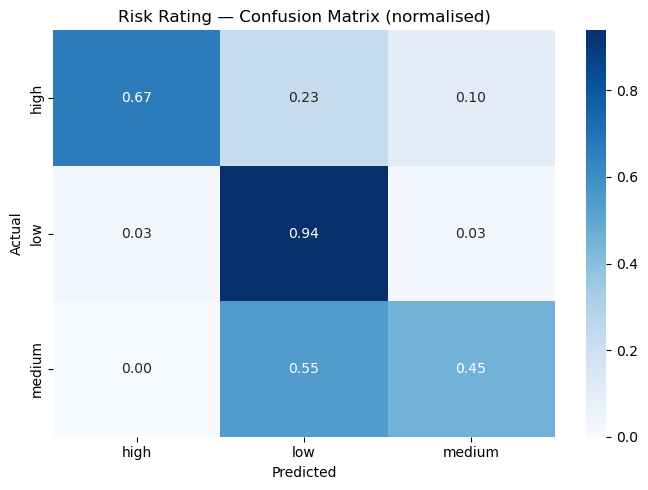

In [13]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Risk Rating — Confusion Matrix (normalised)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/risk_rating_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [11]:
# Save model and artefacts
with open('../outputs/risk_rating_model.pkl', 'wb') as f:
    pickle.dump(clf, f)
with open('../outputs/risk_rating_tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
with open('../outputs/risk_rating_label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Saved to outputs/:")
print("  risk_rating_model.pkl")
print("  risk_rating_tfidf.pkl")
print("  risk_rating_label_encoder.pkl")
print("  risk_rating_confusion_matrix.png")

# Quick inference example
def predict_risk(narrative):
    vec = tfidf.transform([narrative])
    label = le.inverse_transform(clf.predict(vec))[0]
    probs = clf.predict_proba(vec)[0]
    return label, dict(zip(le.classes_, probs.round(3)))

example = "They opened three credit accounts in my name without my consent and I cannot pay my rent."
label, probs = predict_risk(example)
print(f"\nExample prediction: '{label}'")
print(f"Probabilities: {probs}")


Saved to outputs/:
  risk_rating_model.pkl
  risk_rating_tfidf.pkl
  risk_rating_label_encoder.pkl
  risk_rating_confusion_matrix.png

Example prediction: 'low'
Probabilities: {'high': np.float64(0.184), 'low': np.float64(0.796), 'medium': np.float64(0.02)}
